UC1 — Employee Turnover Prediction (Frugal Model)
Hackathon AI and HR | Themes: Frugality, Cybersecurity, Explainability, Ethics

This notebook trains a lightweight machine learning model to predict the probability of employee resignation (Termd) using the anonymized HR dataset generated in UC2.

Objective
Identify employees who are at risk of leaving and understand the key factors behind their potential departure. The approach focuses on building a simple, interpretable, resource-efficient, and fair model.

Prerequisite
Run UC2 first to generate the file named HRDataset_anonymized.csv before using this notebook.

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install shap

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

#SHAP for explainability
try:
    import shap
    shap_available = True
    print(f"SHAP is available (version {shap.__version__}) - explainability enabled")
except ImportError:
    shap_available = False
    print("SHAP is not installed. Install it using: pip install shap")

# for  Visualization 
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Loading the dataset of  anonymized  which is generated from UC2
try:
    df = pd.read_csv('HRDataset_anonymized.csv')
    print(f"Anonymized dataset loaded successfully: {df.shape}")
except FileNotFoundError:
    raise FileNotFoundError(
        "File 'HRDataset_anonymized.csv' not found.\n"
        "Please run UC2 anonymization notebook first."
    )

#showing  turnover rate
print(f"Turnover rate: {df['Termd'].mean():.1%}")

SHAP is available (version 0.51.0) - explainability enabled
Anonymized dataset loaded successfully: (311, 34)
Turnover rate: 33.4%


1. Feature Engineering on the Anonymized Dataset

The anonymized dataset no longer includes the Salary column, which has been replaced by salary_bracket, nor the DOB column, which has been replaced by age_bracket.

In this step, we reconstruct numerical features from these bracket-based variables and create additional explanatory features to improve the model’s performance and interpretability.

In [83]:
ref_date = pd.Timestamp('2019-01-01')

#calculating the  Tenure 
df['DateofHire'] = pd.to_datetime(df['DateofHire'], errors='coerce')
df['tenure_years'] = ((ref_date - df['DateofHire']).dt.days / 365.25).clip(lower=0)

# converting the  salary bracket to midpoint 
def bracket_to_midpoint(b):
    try:
        parts = str(b).replace('k', '').split('-')
        return (int(parts[0]) + int(parts[1])) / 2 * 1000
    except:
        return np.nan

df['salary_mid'] = df['salary_bracket'].apply(bracket_to_midpoint)

# Converting  age bracket to midpoint 
def age_bracket_to_mid(b):
    try:
        parts = str(b).split('-')
        return (int(parts[0]) + int(parts[1])) / 2
    except:
        return np.nan

df['age_mid'] = df['age_bracket'].apply(age_bracket_to_mid)

# now comparing the Salary ratio to department average
dept_salary_mean = df.groupby('Department')['salary_mid'].transform('mean')
df['salary_ratio_dept'] = df['salary_mid'] / dept_salary_mean

# Tenure ratio comparing with department average
dept_tenure_mean = df.groupby('Department')['tenure_years'].transform('mean')
df['tenure_ratio_dept'] = df['tenure_years'] / (dept_tenure_mean + 0.01)

# Manager turnover rate 
df['manager_turnover_rate'] = df.groupby('ManagerID')['Termd'].transform('mean')

# Absences normalising from  tenure
df['absences_per_year'] = df['Absences'] / (df['tenure_years'] + 0.5)

# differnces between low satisfaction and high absences
df['low_sat_high_abs'] = (
    (df['EmpSatisfaction'] <= 2) & (df['Absences'] > 10)
).astype(int)

# Composite of  risk score
df['risk_score'] = (
    (5 - df['EngagementSurvey'])
    + (5 - df['EmpSatisfaction'])
    + (df['DaysLateLast30'].clip(0, 10) / 2)
    + (df['Absences'] / 10)
    + np.where(df['PerfScoreID'] <= 2, 2.0, 0.0)
    + np.where(df['SpecialProjectsCount'] == 0, 0.5, 0.0)
).clip(lower=0)

# our Feature selection 
# Excluded: identifiers, raw dates, and post-turnover columns (TermReason, DateofTermination)
FEATURES = [
    # Original features
    'GenderID', 'MarriedID', 'PerfScoreID', 'FromDiversityJobFairID',
    'DeptID', 'PositionID', 'EngagementSurvey', 'EmpSatisfaction',
    'SpecialProjectsCount', 'DaysLateLast30', 'Absences',
    'tenure_years', 'age_mid', 'salary_ratio_dept', 'risk_score',
    
    # New features
    'tenure_ratio_dept', 'manager_turnover_rate',
    'absences_per_year', 'low_sat_high_abs'
]

TARGET = 'Termd'

df_model = df[FEATURES + [TARGET]].dropna()

print(f"Model dataset: {df_model.shape[0]} rows and {len(FEATURES)} features")

print("\nNew features added:")
print("  tenure_ratio_dept       relative tenure within department")
print("  manager_turnover_rate   turnover rate under the same manager")
print("  absences_per_year       absences normalized by tenure")
print("  low_sat_high_abs        interaction between low satisfaction and high absences")

X = df_model[FEATURES]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nTrain set size: {X_train.shape[0]} | Test set size: {X_test.shape[0]}")

Model dataset: 205 rows and 19 features

New features added:
  tenure_ratio_dept       relative tenure within department
  manager_turnover_rate   turnover rate under the same manager
  absences_per_year       absences normalized by tenure
  low_sat_high_abs        interaction between low satisfaction and high absences

Train set size: 164 | Test set size: 41


2. Exploration of Key Features

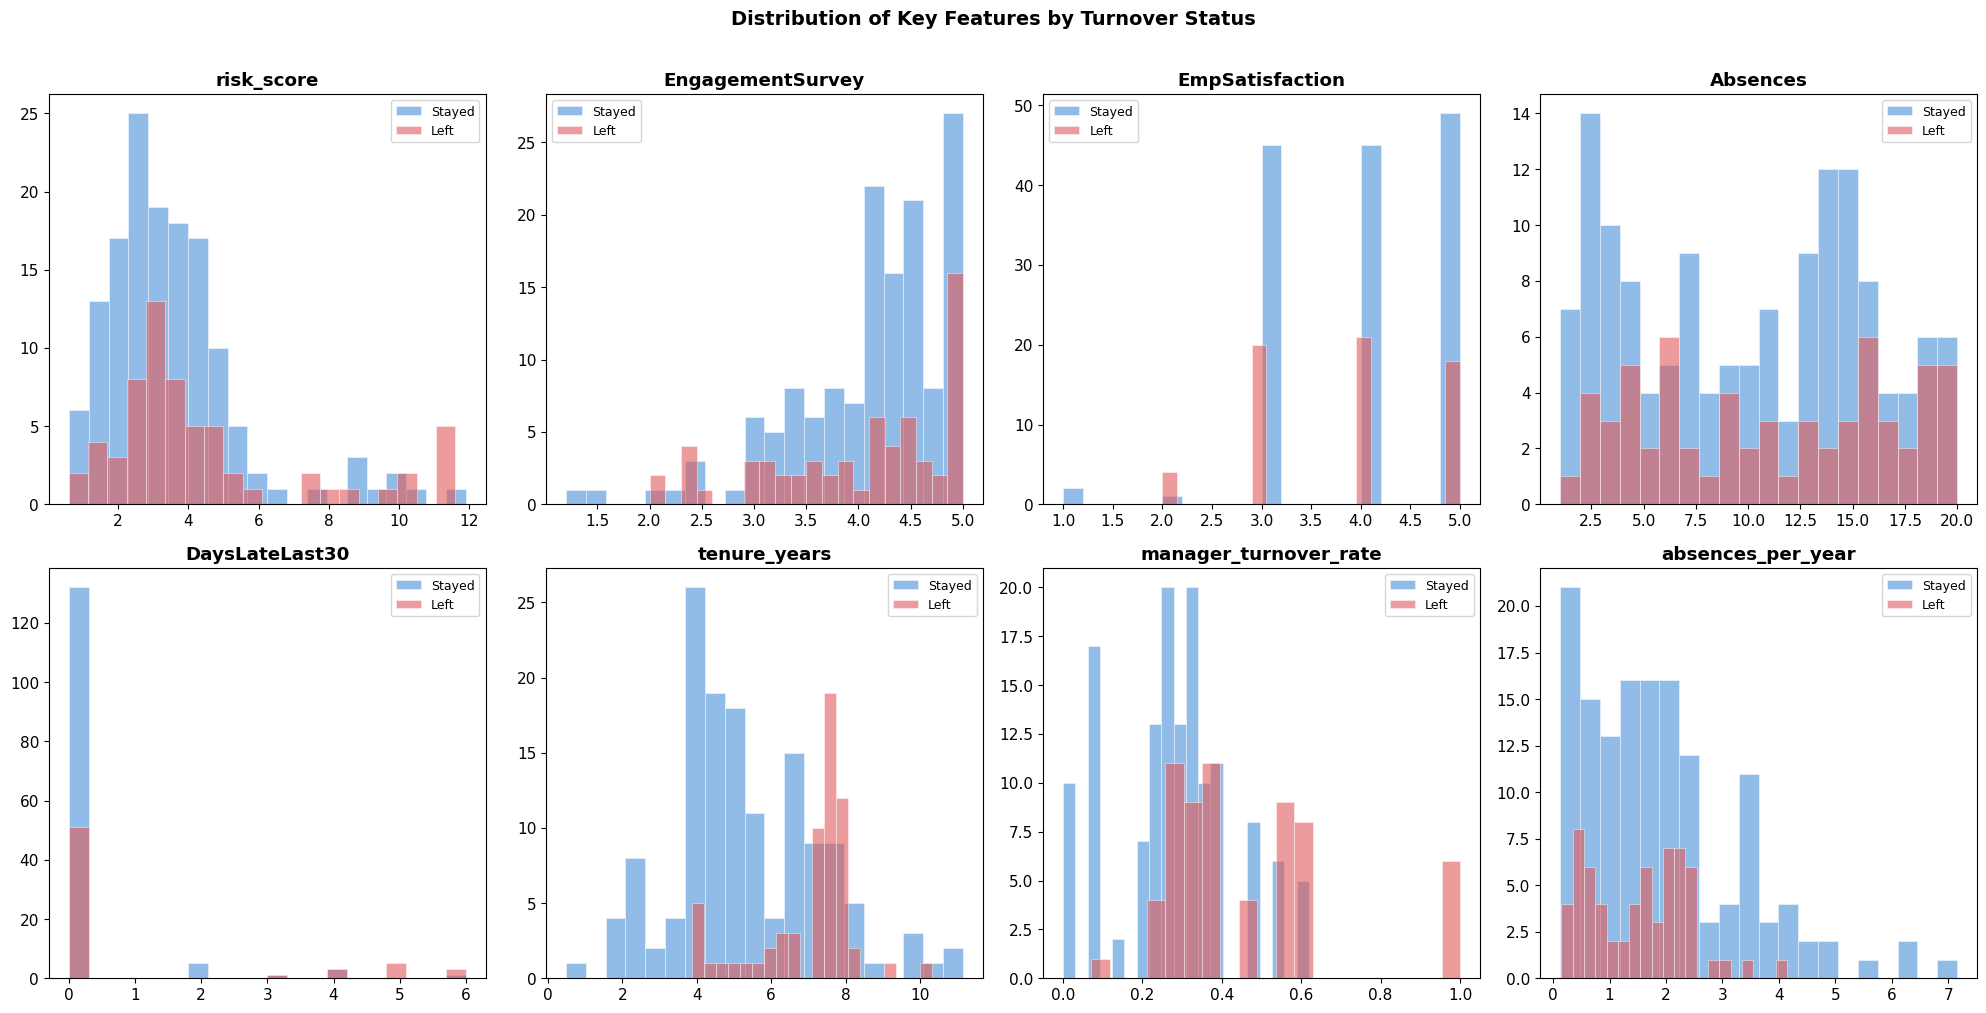

Plot saved as: feature_distributions.png


In [84]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

key_features = [
    'risk_score', 'EngagementSurvey', 'EmpSatisfaction',
    'Absences', 'DaysLateLast30', 'tenure_years',
    'manager_turnover_rate', 'absences_per_year'
]

colors = {'Stayed': '#4A90D9', 'Left': '#E05A5A'}

for ax, feat in zip(axes, key_features):
    for label, val in [(0, 'Stayed'), (1, 'Left')]:
        subset = df_model[df_model[TARGET] == label][feat]
        ax.hist(
            subset,
            bins=20,
            alpha=0.6,
            label=val,
            color=colors[val],
            edgecolor='white',
            linewidth=0.5
        )
    ax.set_title(feat, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle(
    "Distribution of Key Features by Turnover Status",
    fontsize=14,
    fontweight='bold',
    y=1.01
)

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

print("Plot saved as: feature_distributions.png")

3. Training — Logistic Regression (Primary Frugal Model)

In [85]:
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced'
    ))
])

pipe_lr.fit(X_train, y_train)

y_pred_lr = pipe_lr.predict(X_test)
y_proba_lr = pipe_lr.predict_proba(X_test)[:, 1]

cv_scores = cross_val_score(pipe_lr, X, y, cv=5, scoring='roc_auc')

print("Logistic Regression Results")
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=['Stayed (0)', 'Left (1)']
))

print(f"AUC-ROC (test): {roc_auc_score(y_test, y_proba_lr):.3f}")
print(f"AUC-ROC (5-fold CV): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

Logistic Regression Results
              precision    recall  f1-score   support

  Stayed (0)       0.88      0.82      0.85        28
    Left (1)       0.67      0.77      0.71        13

    accuracy                           0.80        41
   macro avg       0.78      0.80      0.78        41
weighted avg       0.82      0.80      0.81        41

AUC-ROC (test): 0.887
AUC-ROC (5-fold CV): 0.843 ± 0.036


4. Training — Decision Tree (Interpretable, Frugal Model)

In [86]:
pipe_dt = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', DecisionTreeClassifier(
        max_depth=5,
        random_state=42,
        class_weight='balanced'
    ))
])

pipe_dt.fit(X_train, y_train)

y_pred_dt = pipe_dt.predict(X_test)
y_proba_dt = pipe_dt.predict_proba(X_test)[:, 1]

print("Decision Tree (max depth = 5)")
print(classification_report(
    y_test,
    y_pred_dt,
    target_names=['Stayed (0)', 'Left (1)']
))

print(f"AUC-ROC: {roc_auc_score(y_test, y_proba_dt):.3f}")

Decision Tree (max depth = 5)
              precision    recall  f1-score   support

  Stayed (0)       0.92      0.79      0.85        28
    Left (1)       0.65      0.85      0.73        13

    accuracy                           0.80        41
   macro avg       0.78      0.82      0.79        41
weighted avg       0.83      0.80      0.81        41

AUC-ROC: 0.837


5. Confusion Matrices and ROC Curves

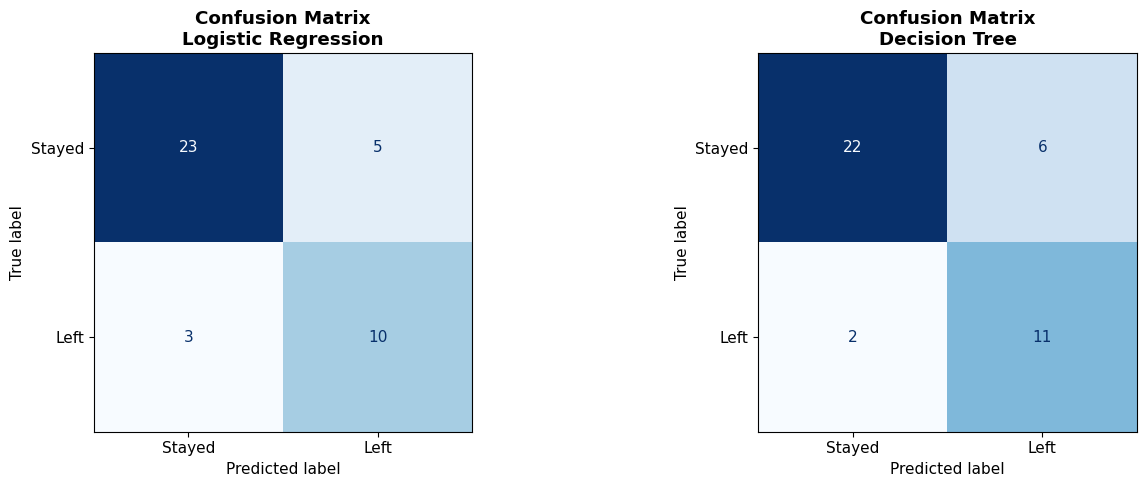

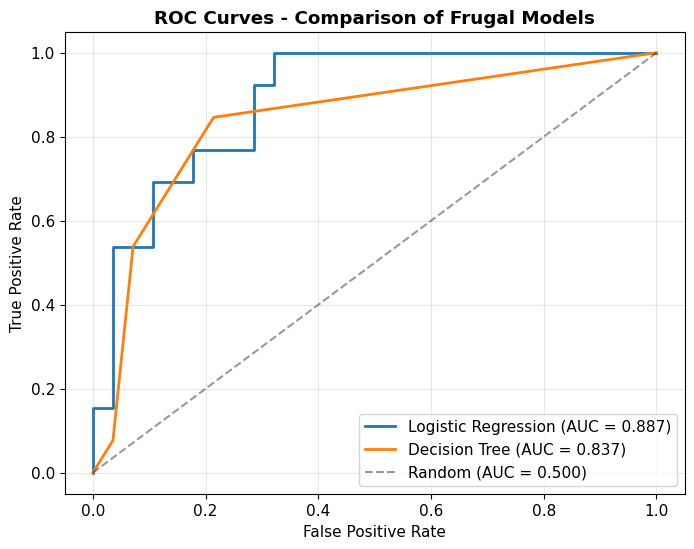

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, y_pred) in zip(
    axes,
    [('Logistic Regression', y_pred_lr),
     ('Decision Tree', y_pred_dt)]
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Stayed', 'Left'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"Confusion Matrix\n{name}", fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()

# Curves of ROC
plt.figure(figsize=(8, 6))

for name, proba in [
    ('Logistic Regression', y_proba_lr),
    ('Decision Tree', y_proba_dt)
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random (AUC = 0.500)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Comparison of Frugal Models', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

plt.savefig('roc_curves.png', dpi=120, bbox_inches='tight')
plt.show()

6. Feature Importance — Logistic Regression Coefficients

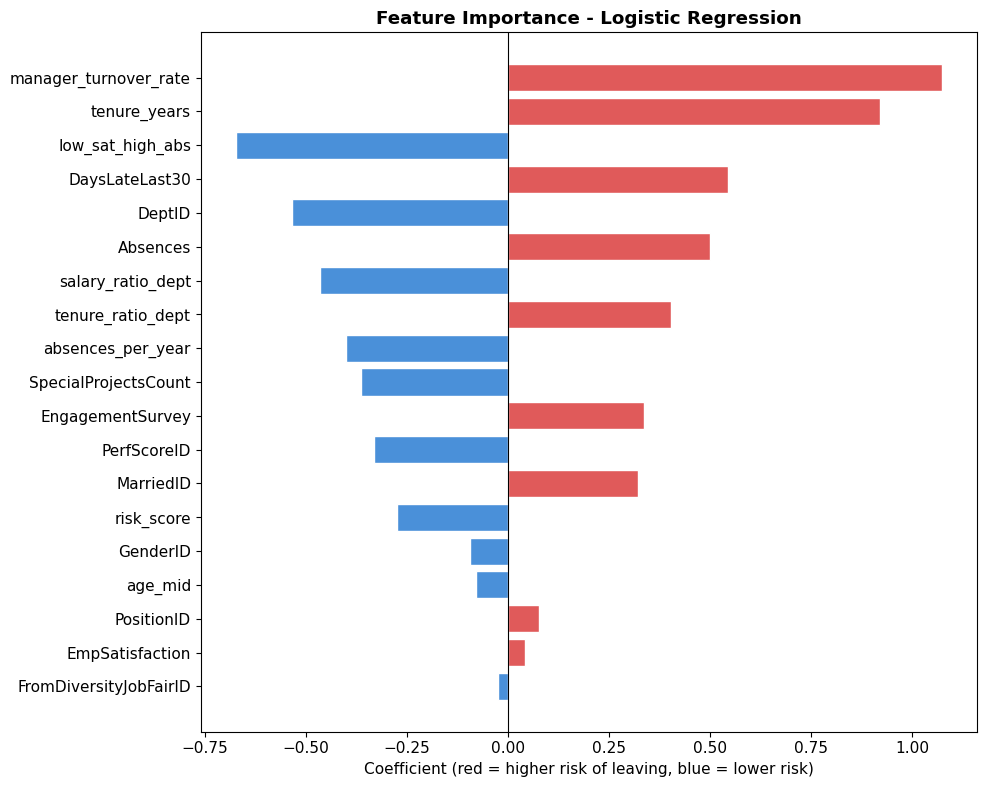


Top 5 factors increasing turnover risk:
              feature  importance
    tenure_ratio_dept    0.404152
             Absences    0.500629
       DaysLateLast30    0.544348
         tenure_years    0.919528
manager_turnover_rate    1.073372

Top 5 factors supporting retention:
               feature  importance
FromDiversityJobFairID   -0.024139
               age_mid   -0.079404
              GenderID   -0.094429
            risk_score   -0.274119
           PerfScoreID   -0.331776


In [88]:
coefs = pipe_lr.named_steps['clf'].coef_[0]

feat_imp = pd.DataFrame({
    'feature': FEATURES,
    'importance': coefs
})

feat_imp['abs_importance'] = feat_imp['importance'].abs()
feat_imp = feat_imp.sort_values('abs_importance', ascending=True)

colors_bar = [
    '#E05A5A' if v > 0 else '#4A90D9'
    for v in feat_imp['importance']
]

plt.figure(figsize=(10, 8))

plt.barh(
    feat_imp['feature'],
    feat_imp['importance'],
    color=colors_bar,
    edgecolor='white'
)

plt.axvline(0, color='black', linewidth=0.8)

plt.xlabel('Coefficient (red = higher risk of leaving, blue = lower risk)')
plt.title('Feature Importance - Logistic Regression', fontweight='bold')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nTop 5 factors increasing turnover risk:")
print(
    feat_imp[feat_imp['importance'] > 0]
    .tail(5)[['feature', 'importance']]
    .to_string(index=False)
)

print("\nTop 5 factors supporting retention:")
print(
    feat_imp[feat_imp['importance'] < 0]
    .head(5)[['feature', 'importance']]
    .to_string(index=False)
)

7. Explainability with XAI — SHAP Analysis

SHAP (SHapley Additive exPlanations) is used to explain how each feature contributes to individual predictions.

It is a recommended method for making machine learning models transparent and understandable, especially for HR decision-makers

SHAP is available (version 0.51.0)


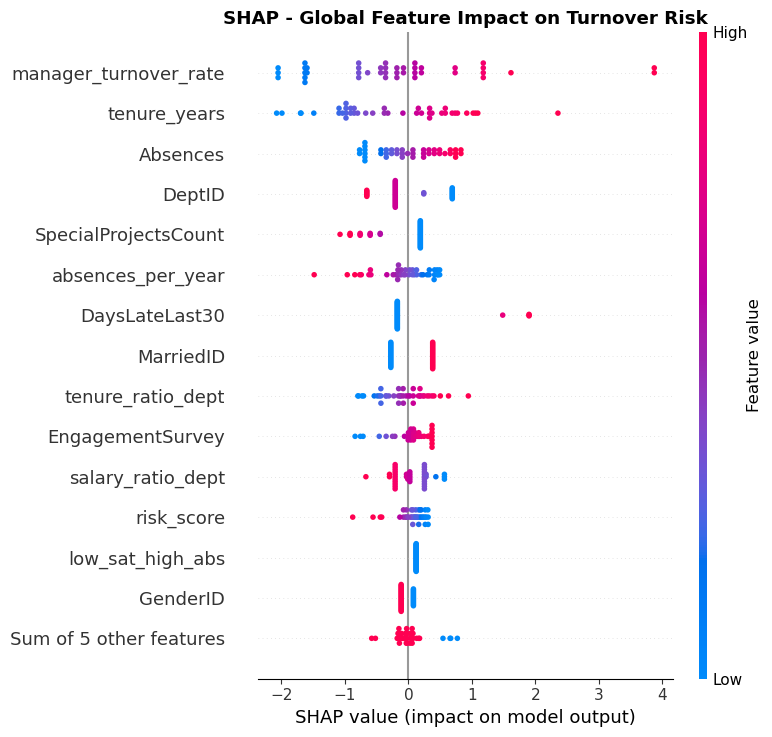

Plot saved as: shap_beeswarm.png


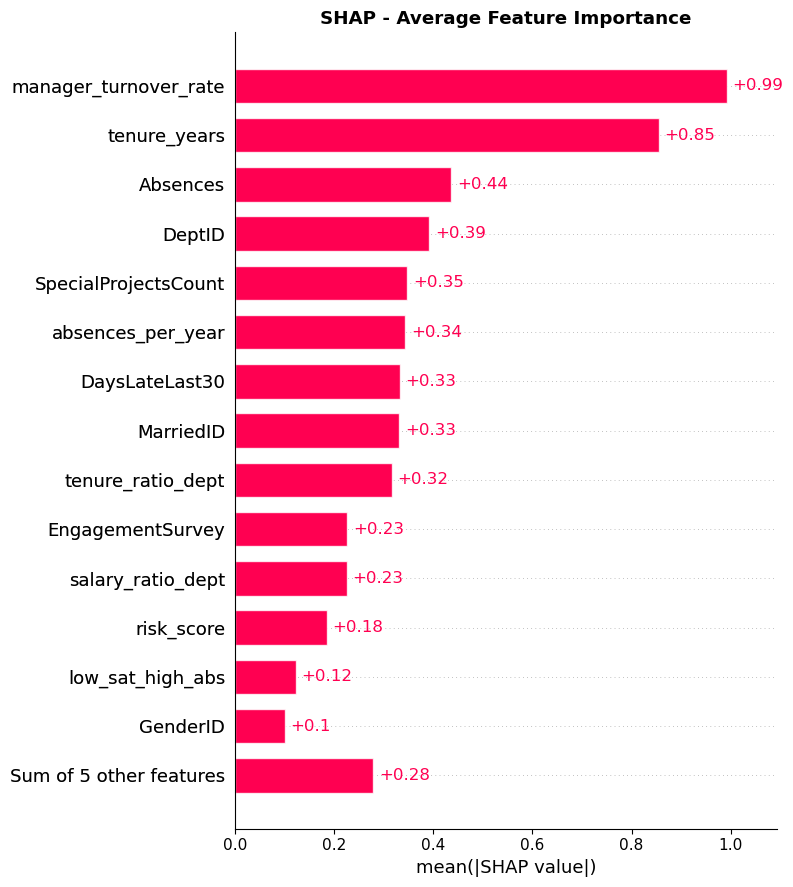

Plot saved as: shap_bar.png


In [89]:
try:
    import shap
    SHAP_OK = True
    print(f"SHAP is available (version {shap.__version__})")
except ImportError:
    SHAP_OK = False
    print("SHAP is not installed. Install it using: pip install shap")
if SHAP_OK:
    # LinearExplainer is suitable for Logistic Regression and remains lightweight
    scaler = pipe_lr.named_steps['scaler']
    clf_lr = pipe_lr.named_steps['clf']

    X_train_scaled = pd.DataFrame(
        scaler.transform(X_train),
        columns=FEATURES
    )
    X_test_scaled = pd.DataFrame(
        scaler.transform(X_test),
        columns=FEATURES
    )

    explainer = shap.LinearExplainer(clf_lr, X_train_scaled)
    shap_values = explainer(X_test_scaled)

    # Global feature impact in beeswarm plot
    plt.figure(figsize=(10, 7))
    shap.plots.beeswarm(shap_values, max_display=15, show=False)
    plt.title(
        'SHAP - Global Feature Impact on Turnover Risk',
        fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig('shap_beeswarm.png', dpi=120, bbox_inches='tight')
    plt.show()

    print("Plot saved as: shap_beeswarm.png")

    # observing Mean SHAP importance from bar plot
    plt.figure(figsize=(10, 7))
    shap.plots.bar(shap_values, max_display=15, show=False)
    plt.title(
        'SHAP - Average Feature Importance',
        fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig('shap_bar.png', dpi=120, bbox_inches='tight')
    plt.show()

    print("Plot saved as: shap_bar.png")

else:
    print("SHAP is not available. Please install it using: pip install shap")

8. Individual Explanation — Why This Employee Is at Risk of Leaving

The goal of this section is to generate a clear and human-readable explanation such as:
"the model predicts that employee X is likely to leave because..."

This is done by using SHAP values to identify the main factors contributing to the prediction for a specific employee

Highest risk employee: EMP_45F65357
Predicted probability of leaving: 98.6%



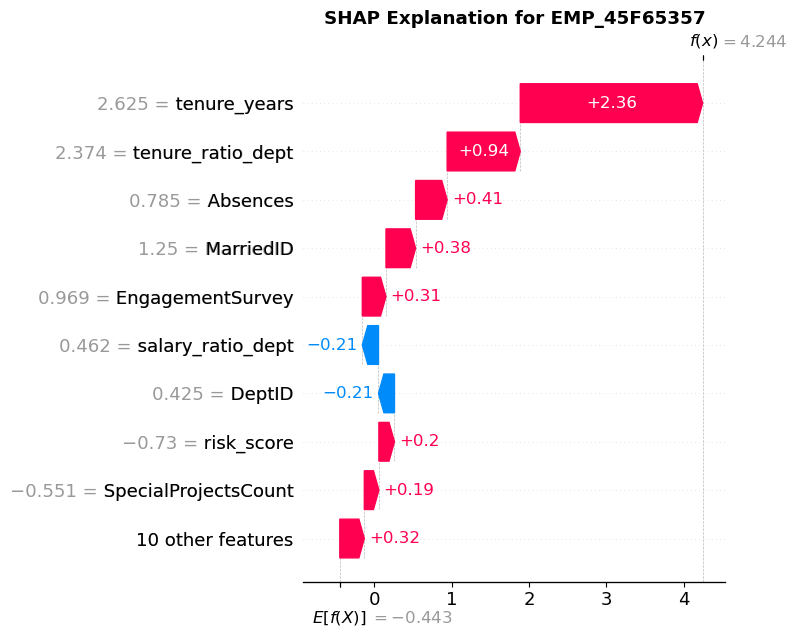

The model predicts that employee EMP_45F65357 has a 99% probability of leaving. The main risk factors are: low tenure, low tenure relative to the department, a high number of absences. Protective factors include: salary below department average, DeptID. Recommended action: prioritize a retention-focused HR discussion.


In [90]:
# Prediction of  turnover probability for active employees
df_active = df[df['EmploymentStatus'] == 'Active'].copy()
df_active_feat = df_active[FEATURES].dropna()
idx_active = df_active_feat.index

probas_active = pipe_lr.predict_proba(df_active_feat)[:, 1]
df_active.loc[idx_active, 'turnover_probability'] = probas_active

# Now Selection of  the employee who is having  highest turnover risk
top_idx = df_active.loc[idx_active].nlargest(1, 'turnover_probability').index[0]
top_emp = df_active.loc[top_idx]
top_emp_id = top_emp['Employee_Name']  
top_proba = top_emp['turnover_probability']

print(f"Highest risk employee: {top_emp_id}")
print(f"Predicted probability of leaving: {top_proba:.1%}")
print()

if SHAP_OK:
    scaler = pipe_lr.named_steps['scaler']
    clf_lr = pipe_lr.named_steps['clf']

    X_train_scaled = pd.DataFrame(
        scaler.transform(X_train),
        columns=FEATURES
    )
    explainer = shap.LinearExplainer(clf_lr, X_train_scaled)

    X_emp = df_active_feat.loc[[top_idx]]
    X_emp_scaled = pd.DataFrame(
        scaler.transform(X_emp),
        columns=FEATURES
    )
    shap_emp = explainer(X_emp_scaled)

    # Here we check with Waterfall plot for this employee
    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(shap_emp[0], show=False)
    plt.title(f'SHAP Explanation for {top_emp_id}', fontweight='bold')
    plt.tight_layout()
    plt.savefig('shap_waterfall_top_employee.png', dpi=120, bbox_inches='tight')
    plt.show()

    #Explanation for human readable
    shap_vals = dict(zip(FEATURES, shap_emp.values[0]))

    top3_risk = sorted(
        shap_vals.items(),
        key=lambda x: x[1],
        reverse=True
    )[:3]

    top3_protect = sorted(
        shap_vals.items(),
        key=lambda x: x[1]
    )[:2]

    label_map = {
        'risk_score': 'a high risk score',
        'EngagementSurvey': 'low engagement',
        'EmpSatisfaction': 'low satisfaction',
        'Absences': 'a high number of absences',
        'DaysLateLast30': 'frequent lateness',
        'manager_turnover_rate': 'a manager with high turnover',
        'tenure_years': 'low tenure',
        'absences_per_year': 'high annual absenteeism',
        'low_sat_high_abs': 'a combination of low satisfaction and high absences',
        'PerfScoreID': 'low performance score',
        'SpecialProjectsCount': 'few special projects',
        'tenure_ratio_dept': 'low tenure relative to the department',
        'salary_ratio_dept': 'salary below department average',
    }

    risk_reasons = [
        label_map.get(feature, feature)
        for feature, value in top3_risk if value > 0
    ]

    protect_reasons = [
        label_map.get(feature, feature)
        for feature, value in top3_protect if value < 0
    ]

    

    sentence = (
        f"The model predicts that employee {top_emp_id} has a "
        f"{top_proba:.0%} probability of leaving."
    )

    if risk_reasons:
        sentence += " The main risk factors are: " + ", ".join(risk_reasons) + "."

    if protect_reasons:
        sentence += " Protective factors include: " + ", ".join(protect_reasons) + "."

    sentence += " Recommended action: prioritize a retention-focused HR discussion."

    print(sentence)
   

else:
    print("SHAP is not available. Narrative explanation is disabled.")

9. Algorithmic Bias Analysis (Ethical AI)

This section evaluates whether the model treats all employees fairly or shows potential signs of discrimination, for example across gender or ethnicity.

The analysis focuses on comparing false positive rates across different groups. A fair model should produce similar error rates for each group, ensuring that no category of employees is disproportionately flagged as being at risk of leaving.

In [94]:
def fairness_report(df_audit, group_col, label):
    rows = []

    for grp, sub in df_audit.groupby(group_col):
        # Debug print to see what's happening
        print(f"{grp}: {len(sub)} samples")

        # Relax the condition (or remove it)
        if len(sub) < 2:
            continue

        tp = ((sub['y_true'] == 1) & (sub['y_pred'] == 1)).sum()
        fp = ((sub['y_true'] == 0) & (sub['y_pred'] == 1)).sum()
        fn = ((sub['y_true'] == 1) & (sub['y_pred'] == 0)).sum()
        tn = ((sub['y_true'] == 0) & (sub['y_pred'] == 0)).sum()

        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan

        n_pos = (sub['y_true'] == 1).sum()
        auc = roc_auc_score(sub['y_true'], sub['y_proba']) \
            if n_pos > 0 and n_pos < len(sub) else np.nan

        rows.append({
            'Group': grp,
            'Count': len(sub),
            'FPR': round(fpr, 3),
            'FNR': round(fnr, 3),
            'AUC': round(auc, 3) if not np.isnan(auc) else 'N/A'
        })

    if len(rows) == 0:
        print(f"No valid groups found for {label}. Check group sizes.")
        return None

    result = pd.DataFrame(rows)

    print(f"\nFairness analysis by {label}")
    print(result.to_string(index=False))

    fpr_vals = result['FPR'].dropna()

    if len(fpr_vals) > 1:
        gap = fpr_vals.max() - fpr_vals.min()
        flag = "Potential bias detected" if gap > 0.10 else "Acceptable fairness"
        print(f"Maximum FPR gap between groups: {gap:.3f} - {flag}")

    return result

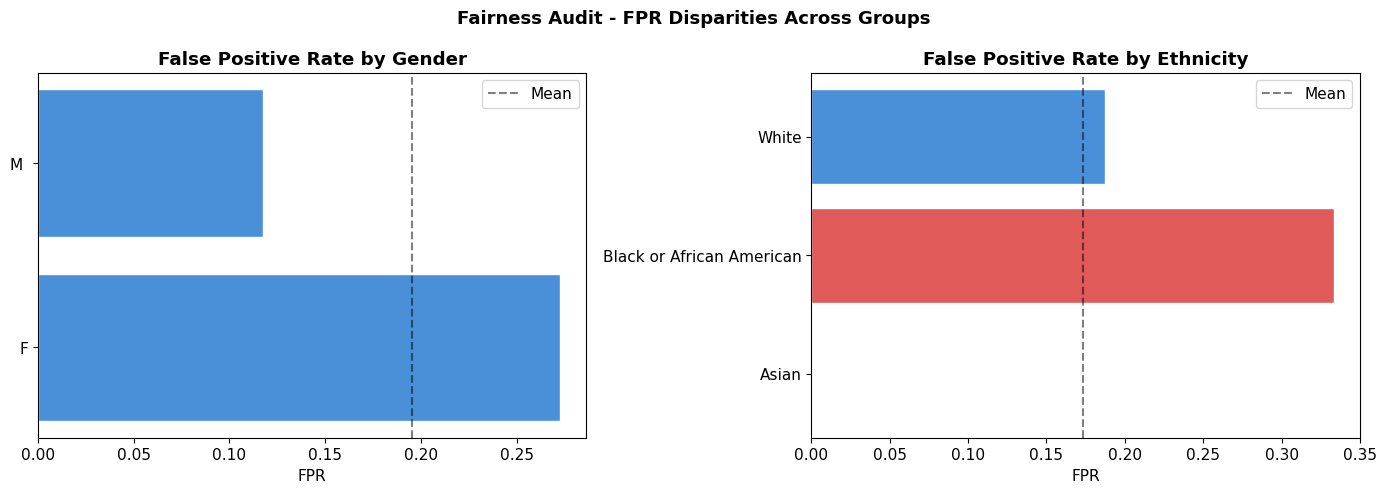

Plot saved as: fairness_audit.png


In [92]:
# visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (col, label) in zip(axes, [('Sex', 'Gender'), ('RaceDesc', 'Ethnicity')]):
    if col not in df_test_audit.columns:
        continue

    rows = []

    for grp, sub in df_test_audit.groupby(col):
        if len(sub) < 5:
            continue

        fp = ((sub['y_true'] == 0) & (sub['y_pred'] == 1)).sum()
        tn = ((sub['y_true'] == 0) & (sub['y_pred'] == 0)).sum()
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

        rows.append({
            'Group': str(grp),
            'FPR': fpr
        })

    df_fair = pd.DataFrame(rows)

    colors_fair = [
        '#E05A5A' if value > 0.3 else '#4A90D9'
        for value in df_fair['FPR']
    ]

    ax.barh(
        df_fair['Group'],
        df_fair['FPR'],
        color=colors_fair,
        edgecolor='white'
    )

    ax.axvline(
        df_fair['FPR'].mean(),
        color='black',
        linestyle='--',
        alpha=0.5,
        label='Mean'
    )

    ax.set_title(f'False Positive Rate by {label}', fontweight='bold')
    ax.set_xlabel('FPR')
    ax.legend()

plt.suptitle(
    'Fairness Audit - FPR Disparities Across Groups',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('fairness_audit.png', dpi=120, bbox_inches='tight')
plt.show()

print("Plot saved as: fairness_audit.png")

10. Export — Risk Scores for Active Employees

The exported file uses pseudonymized identifiers only and does not include any real employee names.

In [93]:
# Rebuilding  the full active employee dataset with features
df_active_full = df[df['EmploymentStatus'] == 'Active'].copy()
df_active_full_feat = df_active_full[FEATURES].dropna()
idx = df_active_full_feat.index

probas = pipe_lr.predict_proba(df_active_full_feat)[:, 1]

df_active_full.loc[idx, 'turnover_probability'] = probas.round(3)
df_active_full.loc[idx, 'risk_score_model'] = df_active_full.loc[idx, 'risk_score']

df_active_full['risk_level'] = pd.cut(
    df_active_full['turnover_probability'],
    bins=[0, 0.35, 0.60, 1.0],
    labels=['Low', 'Moderate', 'High']
)

# Exporting the data using pseudonymized identifiers  
cols_export = [
    'Employee_Name', 'Department', 'Position',
    'turnover_probability', 'risk_level', 'risk_score'
]

df_export = df_active_full.loc[idx, cols_export].sort_values(
    'turnover_probability',
    ascending=False
)

df_export.to_csv('employee_risk_scores.csv', index=False)

print("Risk level distribution:")
print(df_active_full['risk_level'].value_counts())

print("\nExport saved: employee_risk_scores.csv")
print("Pseudonymized identifiers only - GDPR compliance ensured")

print("\nTop 10 employees at highest risk:")
print(df_export.head(10).to_string(index=False))

Risk level distribution:
risk_level
Low         102
Moderate     20
High         20
Name: count, dtype: int64

Export saved: employee_risk_scores.csv
Pseudonymized identifiers only - GDPR compliance ensured

Top 10 employees at highest risk:
Employee_Name        Department                 Position  turnover_probability risk_level  risk_score
 EMP_45F65357 Production         Production Technician I                 0.986       High        2.16
 EMP_3B160FBC Production         Production Technician I                 0.929       High        5.34
 EMP_84DBCEA9 Production              Production Manager                 0.898       High        3.97
 EMP_E8B66810 Production         Production Technician I                 0.896       High        3.30
 EMP_3C72E9C5     Admin Offices           Sr. Accountant                 0.891       High        2.30
 EMP_655125D4 Production         Production Technician I                 0.879       High        2.00
 EMP_0356FF2D Production         Production 